In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import healpy as hp

import sys
sys.path.append("..")
from utils import create_mask as cm

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
# mask
nside = 128
band_mask_range = 2.
r_outer = 25.
mask_ps = hp.ud_grade(np.load(f"../data/mask_3fgl_0p8deg.npy"), nside_out=nside) > 0
mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=band_mask_range, mask_ring=True, inner=0, outer=r_outer, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)
normalization_mask = mask_plane

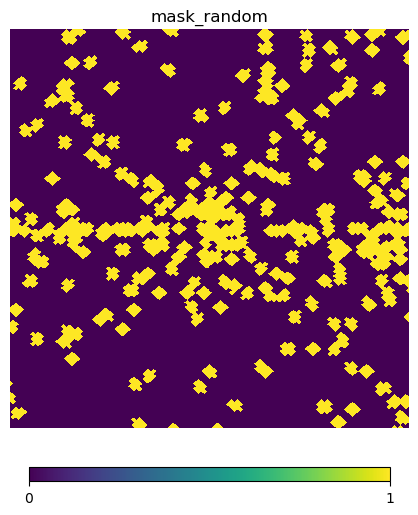

In [5]:
hp.cartview(mask_ps, latra=[-25,25], lonra=[-25,25], title='mask_random')

## clumping

In [19]:
m = np.zeros_like(mask_plane)

In [26]:
m = mask_plane.copy()
ps_count = 0

while np.sum(~m[~normalization_mask]) > np.sum(~mask_roi):

    while True:
        theta = np.arccos(1 - 2 * np.random.rand())  # [0, pi]
        phi = 2 * np.pi * np.random.rand() - np.pi  # [-pi, pi]
        if np.abs(theta-np.pi/2) < np.deg2rad(25.) and np.abs(phi) < np.deg2rad(25.):
            break
    print('.', end='', flush=True)
    vec = hp.ang2vec(theta, phi)
    ipix_disc = hp.query_disc(128, vec, np.deg2rad(0.8))
    m[ipix_disc] = 1

.....................................................................................................................................................................................................................................

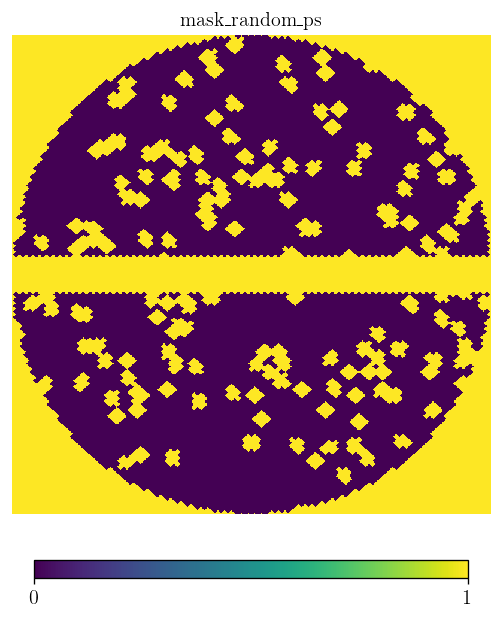

In [28]:
hp.cartview(m, latra=[-25,25], lonra=[-25,25], title='mask_random_ps')

In [30]:
np.save(f"mask_random_ps.npy", m)

## location

In [3]:
from utils.cart import to_cart

In [4]:
z = to_cart(mask_ps, n_pixels=100, pixelsize=0.5)

In [5]:
xs = []
ys = []
for ix in range(100):
    for iy in range(100):
        if z[iy, ix] > 0.5:
            xs.append(ix)
            ys.append(iy)

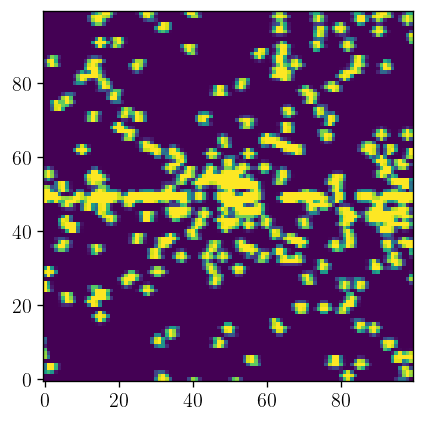

In [6]:
plt.imshow(z, origin='lower')

In [7]:
from jax.scipy.stats import gaussian_kde
import jax.numpy as jnp
import jax

In [21]:
kernel = gaussian_kde(np.array([xs, ys]), bw_method=0.4)

In [22]:
zk = np.zeros((100,100))
for ix in range(100):
    for iy in range(100):
        zk[iy, ix] = kernel.pdf(jnp.array([ix, iy]))

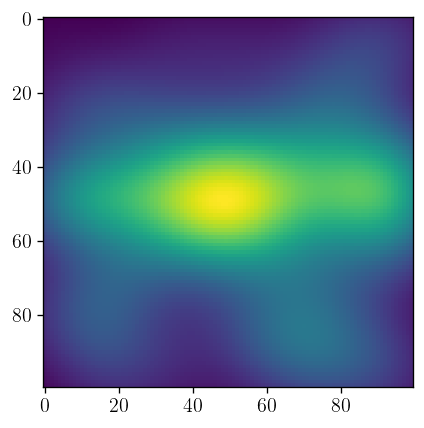

In [23]:
plt.imshow(zk)

In [24]:
# get jax random key
ixs, iys = kernel.resample(jax.random.PRNGKey(42), (5000,))

In [25]:
x_rad = np.deg2rad(ixs * 0.5 - 25.)
y_rad = np.deg2rad(iys * 0.5 - 25.)

In [26]:
m = mask_plane.copy()
i_pix = 0

while np.sum(~m[~normalization_mask]) > np.sum(~mask_roi):

    phi = x_rad[i_pix]
    theta = y_rad[i_pix] + np.pi / 2
    ind = hp.ang2pix(128, theta, phi)
    m[ind] = 1
    i_pix += 1
    print(f'{np.sum(~m[~normalization_mask])} {np.sum(~mask_roi)}', end='\r', flush=True)

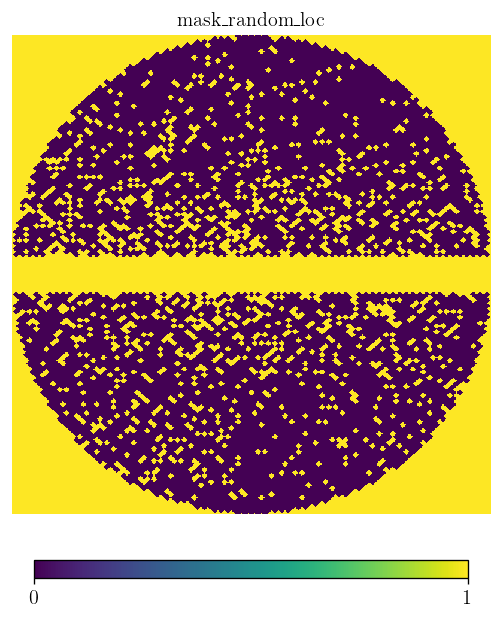

In [27]:
hp.cartview(m, latra=[-25,25], lonra=[-25,25], title='mask_random_loc')

In [20]:
np.save(f"mask_loc.npy", m)